In [1]:
# LOC Isolation Forest + SHAP — ICM Split (icm_ever_owned = 1 vs 0)
# Source: hce_ops_fnl.hce_adr_avtar_like_25_26_f
# Runs the production pipeline separately for each ICM cohort

from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import shap
import matplotlib.pyplot as plt

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\snowflake\connector\vendored\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
engine = create_engine(URL(
    account       = "UHG-UHGDWAAS",
    user          = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role          = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse     = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database      = "VING_PRD_TREND_DB",
    schema        = "TMP_1M"
))

In [3]:
# ── Data Pull — both ICM cohorts

def pull_data(engine, icm_filter, year_range, year_label):
    """Pull hospital_group × market aggregation. icm_filter: None = no filter, 0 or 1 = filter."""
    member_appeal_col = (
        ", count(distinct case when a.member_appeal_ind = 1 then a.case_id end) as member_appeal_cnt"
        if year_label == '2026' else ""
    )
    icm_clause = f"and a.icm_ever_owned = {icm_filter}" if icm_filter is not None else ""
    sql = f"""
        select
            d.collection as hospital_group
            , a.fin_market
            , '{year_label}' as year
            , count(distinct a.case_id) as case_count
            , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
            , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
            , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
            , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
            {member_appeal_col}
        from hce_ops_fnl.hce_adr_avtar_like_25_26_f as a
        left join tmp_1y.tin_collection as d
            on substr(a.fa_prov_id, 2, 9) = d.tin
        where a.fin_brand = 'M&R'
            {icm_clause}
            and a.svc_setting = 'Inpatient'
            and a.admit_cat_cd in ('17 - Medical', '30 - Surgical', '33 - Transplant')
            and to_varchar(a.admit_dt_act, 'MM/dd/yyyy') is not null
            and (
                (a.global_cap = 'NA' and a.sgr_source_name = 'COSMOS'
                 and a.fin_product_level_3 != 'INSTITUTIONAL' and a.tfm_include_flag = 1)
                or (a.sgr_source_name = 'NICE' and a.nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
            )
            and d.collection is not null
            and a.admit_act_month between '{year_range[0]}' and '{year_range[1]}'
        group by 1, 2
        having count(distinct a.case_id) >= 30
    """
    return pd.read_sql(sql, engine)

# Pull for all 3 cohorts: ICM-owned, Non-ICM, All
data = {}
for icm_label, icm_val in [('ICM-owned', 1), ('Non-ICM', 0), ('All', None)]:
    df_25 = pull_data(engine, icm_val, ('202501', '202512'), '2025')
    df_26 = pull_data(engine, icm_val, ('202601', '202607'), '2026')
    data[icm_label] = {'2025': df_25, '2026': df_26}
    print(f"{icm_label}: 2025 = {len(df_25)} rows | 2026 = {len(df_26)} rows")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVJdb9sgFP0rFnu2wZ7zYZSkcht1ST8yL0lXqS8TxjhBxeACjpt%2FP%2BwkUvfQSntAQnDOPefecydX75XwDkwbruQUhAECHpNUFVzupuBpe%2BuPgWcskQURSrIpODIDrmYTQypR47Sxe7lmbw0z1nOFpMHdxxQ0WmJFDDdYkooZbCnepI8POAoQJsYwbZ0cOFMKw53W3toaQ9i2bdB%2BD5TewQghBFECHaqDfAMfJOqvNWqtrKJKXCjvrqdPJEKI4k7CIZxCdiZec3kawVcq%2BQlk8GK7zfzs52YLvPTS3Y2SpqmY3jB94JQ9rR9OBoxz0Ox3vjtFS4j5syeBkaotBXllVFV1Y13NwN1gyQoo1I67SS3nU1C%2F8mJAD4v7tyT5cfwVZmr3Mrqj2XVOn%2B%2FuH1erLF7HWb2I1JI%2FRykF3u9LrlGX69KYhi1ll6Z1Tyga%2BmjkR8k2HGE0xuEwQOPwBXhzlyaXxPbMi%2BXeR1BxqpVRpVVScMl6l0WOBiWhxKfjiPhxnhR%2BntCBj8phnA9Hg0EchbDLLAKnvcG9ET37v2lM4EfueQFXLpPlPFOC06N3q3RF7OeRhUHYv%2FDCL3soZhXhIi0KzYxx0Qmh2hvNiHV7bnXDAJydVP%2Fd9Nlf&RelayState=ver%3A3-hint%3A260092213708478-ETMsDgAAAZ%2Bu2SxRABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEPFKt%2FDNx9vu0iUpPAJwidkAAACQYUfN53M0j6laofXx

In [3]:
# ── Pipeline Functions

# Rate configs (reduced: no appeal_overturn, no mcr_overturn)
rate_configs = {
    'initial_adr':    {'num': 'initial_adr_cnt',    'denom': 'case_count'},
    'persistent_adr': {'num': 'persistent_adr_cnt', 'denom': 'case_count'},
    'p2p_overturn':   {'num': 'p2p_ovrtn_cnt',     'denom': 'initial_adr_cnt'},
    'md_escalation':      {'num': 'md_reviewed_cnt',    'denom': 'case_count'},
}

iso_kpi_6 = [
    'log_case_count', 'log_initial_adr_cnt',
    'initial_adr_adj_rate', 'persistent_adr_adj_rate',
    'p2p_overturn_adj_rate', 'md_escalation_adj_rate'
]
iso_kpi_7 = iso_kpi_6 + ['member_appeal_adj_rate']


def estimate_k_mom(rates, denoms):
    mask = np.isfinite(rates) & (denoms > 0)
    r, n = rates[mask], denoms[mask]
    if len(r) < 10:
        return 50.0
    p_bar = r.mean()
    v_obs = r.var(ddof = 1)
    n_harm = len(n) / np.sum(1.0 / n)
    v_samp = p_bar * (1 - p_bar) / n_harm
    v_signal = v_obs - v_samp
    if v_signal <= 0:
        return 50.0
    alpha = p_bar * (p_bar * (1 - p_bar) / v_signal - 1)
    beta = (1 - p_bar) * (p_bar * (1 - p_bar) / v_signal - 1)
    if alpha <= 0 or beta <= 0:
        return 50.0
    return alpha + beta


def run_pipeline(df_25, df_26, label):
    """Run full IF pipeline for one ICM cohort. Returns dict of results."""
    df = pd.concat([df_25, df_26], ignore_index = True)

    # k estimation (pooled)
    k_map = {}
    for feat, cfg in rate_configs.items():
        rates = df[cfg['num']] / df[cfg['denom']].replace(0, np.nan)
        k_map[feat] = estimate_k_mom(rates.values, df[cfg['denom']].values)

    # member appeal k (2026 only)
    df_26_only = df[df['year'] == '2026'].copy()
    if 'member_appeal_cnt' in df_26_only.columns:
        rates_ma = df_26_only['member_appeal_cnt'] / df_26_only['initial_adr_cnt'].replace(0, np.nan)
        k_map['member_appeal'] = estimate_k_mom(rates_ma.values, df_26_only['initial_adr_cnt'].values)

    # global rates (full >=30 pop)
    global_rates = {}
    for feat, cfg in rate_configs.items():
        global_rates[feat] = df[cfg['num']].sum() / df[cfg['denom']].sum()
    if 'member_appeal_cnt' in df_26_only.columns:
        global_rates['member_appeal'] = df_26_only['member_appeal_cnt'].sum() / df_26_only['initial_adr_cnt'].sum()

    # shrinkage (>=10 ADR filter)
    def shrink(num, denom, k, p_global):
        return (num + k * p_global) / (denom + k)

    df_model = df[df['initial_adr_cnt'] >= 10].copy()
    for feat, cfg in rate_configs.items():
        df_model[f"{feat}_adj_rate"] = shrink(df_model[cfg['num']], df_model[cfg['denom']], k_map[feat], global_rates[feat])

    if 'member_appeal_cnt' in df_model.columns:
        df_model['member_appeal_adj_rate'] = np.where(
            df_model['year'] == '2026',
            shrink(df_model['member_appeal_cnt'], df_model['initial_adr_cnt'], k_map['member_appeal'], global_rates['member_appeal']),
            np.nan
        )

    df_model = df_model.assign(
        log_case_count = lambda x: np.log1p(x['case_count']),
        log_initial_adr_cnt = lambda x: np.log1p(x['initial_adr_cnt'])
    )

    # split by year
    df_25m = df_model[df_model['year'] == '2025'].copy()
    df_26m = df_model[df_model['year'] == '2026'].copy()

    # bootstrap stability
    def bootstrap_flags(df_year, features, n_iter = 200, pct = 2.5, random_state = 42):
        rng = np.random.RandomState(random_state)
        n = len(df_year)
        if n < 10:
            return np.zeros(n)
        flag_counts = np.zeros(n)
        for i in range(n_iter):
            idx = rng.choice(n, size = n, replace = True)
            X_boot = df_year[features].iloc[idx].values
            model = IsolationForest(n_estimators = 300, contamination = 'auto', random_state = i)
            model.fit(X_boot)
            scores = model.decision_function(df_year[features].values)
            threshold = np.percentile(scores, pct)
            flag_counts += (scores <= threshold).astype(int)
        return flag_counts / n_iter

    print(f"  {label} — bootstrapping 2025 ({len(df_25m)} hospitals)...")
    df_25m['bootstrap_flag_pct'] = bootstrap_flags(df_25m, iso_kpi_6)
    print(f"  {label} — bootstrapping 2026 ({len(df_26m)} hospitals)...")
    df_26m['bootstrap_flag_pct'] = bootstrap_flags(df_26m, iso_kpi_7)

    df_25m['consensus_flag'] = df_25m['bootstrap_flag_pct'] >= 0.50
    df_26m['consensus_flag'] = df_26m['bootstrap_flag_pct'] >= 0.50

    # SHAP
    def compute_shap(df_year, features):
        model = IsolationForest(n_estimators = 300, contamination = 'auto', random_state = 42)
        model.fit(df_year[features])
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(df_year[features])
        min_idx = np.argmin(shap_vals, axis = 1)
        drivers = [features[i] for i in min_idx]
        medians = {f: df_year[f].median() for f in features}
        directions = [
            'HIGH' if df_year[feat].iloc[row] > medians[feat] else 'LOW'
            for row, feat in enumerate(drivers)
        ]
        df_year['shap_driver'] = drivers
        df_year['driver_direction'] = directions
        return df_year, shap_vals

    df_25m, shap_25 = compute_shap(df_25m, iso_kpi_6)
    df_26m, shap_26 = compute_shap(df_26m, iso_kpi_7)

    print(f"  {label} — 2025 flagged: {df_25m['consensus_flag'].sum()} | 2026 flagged: {df_26m['consensus_flag'].sum()}")

    return {
        '2025': df_25m, '2026': df_26m,
        'shap_25': shap_25, 'shap_26': shap_26,
        'k_map': k_map
    }

print("Pipeline functions defined.")

Pipeline functions defined.


In [4]:
# ── Run Pipeline (or load cached results)
import pickle
from pathlib import Path

CACHE_PATH = Path(r'c:\Users\knguy139\Documents\Projects\LOC\Scripts\icm_check_results_202607.pkl')

if CACHE_PATH.exists():
    with open(CACHE_PATH, 'rb') as f:
        results = pickle.load(f)
    print(f"Loaded cached results from {CACHE_PATH}")
    for icm_label, r in results.items():
        print(f"  {icm_label}: 2025 = {r['2025']['consensus_flag'].sum()} flagged | 2026 = {r['2026']['consensus_flag'].sum()} flagged")
else:
    results = {}
    for icm_label in ['ICM-owned', 'Non-ICM', 'All']:
        print(f"\n{'=' * 60}")
        print(f"Running pipeline: {icm_label}")
        print(f"{'=' * 60}")
        results[icm_label] = run_pipeline(
            data[icm_label]['2025'],
            data[icm_label]['2026'],
            icm_label
        )

    # Cache results
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(results, f)
    print(f"\nResults cached to {CACHE_PATH}")

Loaded cached results from c:\Users\knguy139\Documents\Projects\LOC\Scripts\icm_check_results_202607.pkl
  ICM-owned: 2025 = 30 flagged | 2026 = 22 flagged
  Non-ICM: 2025 = 1 flagged | 2026 = 0 flagged
  All: 2025 = 31 flagged | 2026 = 24 flagged


In [6]:
# ── Build Output Tables (matching production format)
DRIVER_RENAME = {
    'md_escalation_adj_rate': 'MD Escalation Rate',
    'member_appeal_adj_rate': 'Member Appeal Rate',
    'persistent_adr_adj_rate': 'Persistent ADR Rate',
    'initial_adr_adj_rate': 'Initial ADR Rate',
    'p2p_overturn_adj_rate': 'P2P Overturn Rate',
    'log_case_count': 'Case Count',
    'log_initial_adr_cnt': 'Initial ADR Count',
}

def build_output(df_year, features):
    out = df_year.copy()
    out['driver'] = out['shap_driver'].map(DRIVER_RENAME).fillna(out['shap_driver'])
    out['direction'] = out['driver_direction']
    out['reason'] = out['driver'] + ' (' + out['direction'] + ')'
    out['driver_value'] = [out.loc[idx, out.loc[idx, 'shap_driver']] for idx in out.index]
    out['driver_adj_median'] = out['shap_driver'].map({f: out[f].median() for f in features})
    out['driver_dev_pct'] = np.where(
        out['driver_adj_median'] != 0,
        (out['driver_value'] - out['driver_adj_median']) / out['driver_adj_median'],
        0
    )
    out['anomaly_rank'] = out['anomaly_score'].rank(method = 'dense').astype(int) if 'anomaly_score' in out.columns else np.nan
    return out

# Build for each cohort
outputs = {}
for icm_label in ['ICM-owned', 'Non-ICM', 'All']:
    r = results[icm_label]
    out_25 = build_output(r['2025'], iso_kpi_6)
    out_26 = build_output(r['2026'], iso_kpi_7)
    df_out = pd.concat([out_25, out_26], ignore_index = True)
    df_flagged = df_out[df_out['consensus_flag']].copy()
    df_flagged['cohort'] = icm_label
    outputs[icm_label] = df_flagged

    print(f"\n{icm_label}: {len(df_flagged)} flagged ({len(df_flagged[df_flagged['year'] == '2025'])} in 2025, {len(df_flagged[df_flagged['year'] == '2026'])} in 2026)")


ICM-owned: 52 flagged (30 in 2025, 22 in 2026)

Non-ICM: 1 flagged (1 in 2025, 0 in 2026)

All: 55 flagged (31 in 2025, 24 in 2026)


In [7]:
# ── Overlap Analysis: 3-way comparison
for yr in ['2025', '2026']:
    sets = {}
    for icm_label in ['ICM-owned', 'Non-ICM', 'All']:
        df_yr = outputs[icm_label]
        sets[icm_label] = set(
            df_yr[df_yr['year'] == yr][['hospital_group', 'fin_market']].apply(tuple, axis = 1)
        )

    print(f"\n{'=' * 60}")
    print(f" {yr} — Overlap Summary")
    print(f"{'=' * 60}")
    print(f"  ICM-owned flagged: {len(sets['ICM-owned'])}")
    print(f"  Non-ICM flagged:   {len(sets['Non-ICM'])}")
    print(f"  All flagged:       {len(sets['All'])}")
    print(f"")
    print(f"  In all 3:          {len(sets['ICM-owned'] & sets['Non-ICM'] & sets['All'])}")
    print(f"  ICM ∩ All:         {len(sets['ICM-owned'] & sets['All'])}")
    print(f"  Non-ICM ∩ All:     {len(sets['Non-ICM'] & sets['All'])}")
    print(f"  ICM ∩ Non-ICM:     {len(sets['ICM-owned'] & sets['Non-ICM'])}")
    print(f"  ICM-only:          {len(sets['ICM-owned'] - sets['Non-ICM'] - sets['All'])}")
    print(f"  Non-ICM-only:      {len(sets['Non-ICM'] - sets['ICM-owned'] - sets['All'])}")
    print(f"  All-only:          {len(sets['All'] - sets['ICM-owned'] - sets['Non-ICM'])}")


 2025 — Overlap Summary
  ICM-owned flagged: 30
  Non-ICM flagged:   1
  All flagged:       31

  In all 3:          0
  ICM ∩ All:         15
  Non-ICM ∩ All:     0
  ICM ∩ Non-ICM:     0
  ICM-only:          15
  Non-ICM-only:      1
  All-only:          16

 2026 — Overlap Summary
  ICM-owned flagged: 22
  Non-ICM flagged:   0
  All flagged:       24

  In all 3:          0
  ICM ∩ All:         16
  Non-ICM ∩ All:     0
  ICM ∩ Non-ICM:     0
  ICM-only:          6
  Non-ICM-only:      0
  All-only:          8


In [8]:
# ── Browse Full Flagged DataFrames (production format)
df_all_flagged = (
    pd.concat(outputs.values(), ignore_index = True)
    .sort_values(['cohort', 'year', 'bootstrap_flag_pct'], ascending = [True, True, False])
    [['cohort', 'year', 'hospital_group', 'fin_market', 'case_count', 'initial_adr_cnt',
      'bootstrap_flag_pct', 'driver', 'direction', 'reason',
      'driver_value', 'driver_adj_median', 'driver_dev_pct']]
)

print(f"Total flagged rows (all cohorts x years): {len(df_all_flagged)}")
df_all_flagged

Total flagged rows (all cohorts x years): 108


,cohort,year,hospital_group,fin_market,case_count,initial_adr_cnt,bootstrap_flag_pct,driver,direction,reason,driver_value,driver_adj_median,driver_dev_pct
55,All,2025,OKLAHOMA SPINE HOSPITAL,OK,138,10,1.000,MD Escalation Rate,LOW,MD Escalation Rate (LOW),0.065897,0.700686,-0.905953
57,All,2025,HCA INC,FL,32262,14061,1.000,Case Count,HIGH,Case Count (HIGH),10.381676,5.484797,0.892810
58,All,2025,LORETTO HOSPITAL,IL,31,21,1.000,Persistent ADR Rate,HIGH,Persistent ADR Rate (HIGH),0.419666,0.148664,1.822918
59,All,2025,Steward,FL,2709,1478,1.000,Persistent ADR Rate,HIGH,Persistent ADR Rate (HIGH),0.388503,0.148664,1.613295
60,All,2025,HEALTH CARE AUTHORITY OF THE CITY OF ANN,AL,860,30,1.000,MD Escalation Rate,LOW,MD Escalation Rate (LOW),0.064067,0.700686,-0.908565
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,ICM-owned,2026,Integris Baptist Med Ctr OK,OK,2104,548,0.780,Member Appeal Rate,HIGH,Member Appeal Rate (HIGH),0.338745,0.009464,34.794768
40,ICM-owned,2026,SSM Health Missouri,MO,4959,2009,0.655,Member Appeal Rate,HIGH,Member Appeal Rate (HIGH),0.185329,0.009464,18.583534
31,ICM-owned,2026,Santa Clara Health System,CA-N,45,31,0.640,Persistent ADR Rate,HIGH,Persistent ADR Rate (HIGH),0.479132,0.178793,1.679809
43,ICM-owned,2026,University of Toledo,OH,137,22,0.570,MD Escalation Rate,LOW,MD Escalation Rate (LOW),0.307134,0.806277,-0.619071


In [9]:
display(
    df_all_flagged
    .query('cohort == "All" and year == "2026"')
    [['hospital_group', 'fin_market', 'reason', 'driver_value']]
    .drop_duplicates()
    .sort_values(['hospital_group', 'fin_market', 'reason'])
    .style.hide(axis='index')
)


hospital_group,fin_market,reason,driver_value
ADVOCATE HEALTH & HOSPITALS IL,IL,MD Escalation Rate (LOW),0.014701
Ascension MI,MI,MD Escalation Rate (LOW),0.020716
Atrium Health System,NC,Member Appeal Rate (HIGH),0.709914
Atrium Health System,SC,Member Appeal Rate (HIGH),0.687217
Aurora Medical Group,WI,Member Appeal Rate (HIGH),0.153326
Baptist Health Kentucky,KY,MD Escalation Rate (LOW),0.035824
Baptist SFL,FL,MD Escalation Rate (LOW),0.303976
CATHOLIC HEALTHCARE WEST,CA-N,MD Escalation Rate (LOW),0.106828
Englewood Hospital,NJ,Persistent ADR Rate (HIGH),0.435532
FLOYD HEALTHCARE MANAGEMENT,AL,Member Appeal Rate (HIGH),0.453146


In [13]:
display(
    df_all_flagged
    .query('hospital_group == "%Valley View%"')
    [['hospital_group', 'fin_market', 'reason', 'driver_value']]
    .drop_duplicates()
    .sort_values(['hospital_group', 'fin_market', 'reason'])
    .style.hide(axis='index')
)


df_all_flagged[df_all_flagged['hospital_group'].str.contains('Valley View', case=False, na=False)]


hospital_group,fin_market,reason,driver_value


,cohort,year,hospital_group,fin_market,case_count,initial_adr_cnt,bootstrap_flag_pct,driver,direction,reason,driver_value,driver_adj_median,driver_dev_pct
75,All,2025,VALLEY VIEW HOSPITAL ASSOCIATION,CO,244,16,0.98,MD Escalation Rate,LOW,MD Escalation Rate (LOW),0.004995,0.700686,-0.992871


In [14]:
df_all_flagged

,cohort,year,hospital_group,fin_market,case_count,initial_adr_cnt,bootstrap_flag_pct,driver,direction,reason,driver_value,driver_adj_median,driver_dev_pct
55,All,2025,OKLAHOMA SPINE HOSPITAL,OK,138,10,1.000,MD Escalation Rate,LOW,MD Escalation Rate (LOW),0.065897,0.700686,-0.905953
57,All,2025,HCA INC,FL,32262,14061,1.000,Case Count,HIGH,Case Count (HIGH),10.381676,5.484797,0.892810
58,All,2025,LORETTO HOSPITAL,IL,31,21,1.000,Persistent ADR Rate,HIGH,Persistent ADR Rate (HIGH),0.419666,0.148664,1.822918
59,All,2025,Steward,FL,2709,1478,1.000,Persistent ADR Rate,HIGH,Persistent ADR Rate (HIGH),0.388503,0.148664,1.613295
60,All,2025,HEALTH CARE AUTHORITY OF THE CITY OF ANN,AL,860,30,1.000,MD Escalation Rate,LOW,MD Escalation Rate (LOW),0.064067,0.700686,-0.908565
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,ICM-owned,2026,Integris Baptist Med Ctr OK,OK,2104,548,0.780,Member Appeal Rate,HIGH,Member Appeal Rate (HIGH),0.338745,0.009464,34.794768
40,ICM-owned,2026,SSM Health Missouri,MO,4959,2009,0.655,Member Appeal Rate,HIGH,Member Appeal Rate (HIGH),0.185329,0.009464,18.583534
31,ICM-owned,2026,Santa Clara Health System,CA-N,45,31,0.640,Persistent ADR Rate,HIGH,Persistent ADR Rate (HIGH),0.479132,0.178793,1.679809
43,ICM-owned,2026,University of Toledo,OH,137,22,0.570,MD Escalation Rate,LOW,MD Escalation Rate (LOW),0.307134,0.806277,-0.619071


In [ ]:
# ── Monthly CSV output for flagged hospitals (with cohort)

# Build flagged lookup per cohort — one row per hospital × cohort
# reason formatted as "driver (dir) (year); driver (dir) (year)" if flagged both years
flagged_lookups = []
for icm_label, df_flagged in outputs.items():
    lk = df_flagged[['hospital_group', 'fin_market', 'year', 'bootstrap_flag_pct', 'reason']].copy()
    lk['reason'] = lk['reason'] + ' (' + lk['year'] + ')'
    lk['bootstrap_flag_pct'] = lk['bootstrap_flag_pct'].apply(lambda v: f"{v:.1%}")

    lk_agg = (
        lk.groupby(['hospital_group', 'fin_market'])
        .agg(
            reason = ('reason', '; '.join),
            bootstrap_flag_pct = ('bootstrap_flag_pct', '; '.join),
        )
        .reset_index()
    )
    lk_agg['cohort'] = icm_label
    flagged_lookups.append(lk_agg)

flagged_lookup = pd.concat(flagged_lookups, ignore_index = True)
flagged_hospitals = set(flagged_lookup['hospital_group'])

# Pull monthly data for flagged hospitals — grouped by icm_ever_owned
df_monthly = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , a.icm_ever_owned
        , a.admit_act_month as hce_admit_month
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
    from hce_ops_fnl.hce_adr_avtar_like_25_26_f as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where a.fin_brand = 'M&R'
        and a.svc_setting = 'Inpatient'
        and a.admit_cat_cd in ('17 - Medical', '30 - Surgical', '33 - Transplant')
        and to_varchar(a.admit_dt_act, 'MM/dd/yyyy') is not null
        and (
            (a.global_cap = 'NA' and a.sgr_source_name = 'COSMOS'
             and a.fin_product_level_3 != 'INSTITUTIONAL' and a.tfm_include_flag = 1)
            or (a.sgr_source_name = 'NICE' and a.nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and d.collection is not null
        and a.admit_act_month between '202501' and '202606'
    group by 1, 2, 3, 4
""", engine)

df_monthly = df_monthly[df_monthly['hospital_group'].isin(flagged_hospitals)].copy()
df_monthly['year'] = df_monthly['hce_admit_month'].str[:4]

# Collapse flag metadata to one row per hospital (across all cohorts that flagged it)
flagged_combined = (
    flagged_lookup.groupby(['hospital_group', 'fin_market'])
    .agg(
        flagged_in_cohort = ('cohort', '; '.join),
        reason = ('reason', '; '.join),
        bootstrap_flag_pct = ('bootstrap_flag_pct', '; '.join),
    )
    .reset_index()
)

# Merge — one set of monthly rows per hospital, no duplication
df_monthly = df_monthly.merge(flagged_combined, on = ['hospital_group', 'fin_market'], how = 'inner')

total_cases = df_monthly.groupby('hospital_group')['case_count'].sum().rename('total_cases')
df_monthly = df_monthly.merge(total_cases, on = 'hospital_group')
df_monthly = df_monthly.sort_values(['total_cases', 'hospital_group', 'icm_ever_owned', 'hce_admit_month'], ascending = [False, True, False, True])

df_monthly_out = df_monthly[[
    'hospital_group', 'fin_market', 'flagged_in_cohort', 'reason', 'bootstrap_flag_pct',
    'icm_ever_owned', 'year', 'hce_admit_month',
    'case_count', 'md_reviewed_cnt', 'initial_adr_cnt', 'persistent_adr_cnt', 'p2p_ovrtn_cnt'
]].copy()

print(f"Monthly output: {len(df_monthly_out)} rows across {df_monthly_out['hospital_group'].nunique()} hospitals")
print(df_monthly_out.to_csv(index = False))

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVLRbtowFP2VyHtO4oSEFguooKiMqWtZoe3Ky%2BQkTvDq2KmvQ2BfPyeA1D200h4sWfY595x7zx1e7Uvh7JgGruQIBR5GDpOpyrgsRuhxfeNeIgcMlRkVSrIROjBAV%2BMh0FJUZFKbrXxgbzUD49hCEkj7MUK1lkRR4EAkLRkQk5LV5PstCT1MKADTxsqhEyUDbrW2xlTE95um8Zqep3ThhxhjHw98i2ohX9A7iepzjUoro1IlzpS97ekDicDHUSthEVZheSJOuTyO4DOV5AgC8nW9XrrL%2B9UaOZNzd9dKQl0yvWJ6x1P2%2BHB7NADWQb0tXHuyhlL4taUeSNXkgr6yVJVVbWxNz978nGW%2BUAW3k1rMRqh65dleq7t4On97iud%2Fos03Ci%2FTC73ZJVFx%2FzswP15%2BTmFeHJ6fe9Vripync65hm%2BsCoGYL2aZp7BMO%2By4euDhYBz2CA9KLvCgcbJAzs2lySU3HPFvufHglT7UClRslBZesc5klOM5pSt30MqRulAwyNxmksYvzfpT0L%2BI4CgO%2FzSxEx70hnRE9%2Fr9pDP333NMC3tlMFrOlEjw9ODdKl9R8HFngBd0Lz9y8gxJWUi4mWaYZgI1OCNVca0aN3XOja4b88VH1300f%2FwU%3D&RelayState=ver%3A3-hint%3A260092298610362-ETMsDgAAAaBdD4ldABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEMy%2BHoNvE%2FtYamVDhD9V5BQAAACQ5QUDzLLb

In [ ]:
# ── TIN lookup for flagged hospitals (separate reference table)

df_tin_lookup = pd.read_sql("""
    select distinct
        d.collection as hospital_group
        , a.fin_market
        , substr(a.fa_prov_id, 2, 9) as tin
    from hce_ops_fnl.hce_adr_avtar_like_25_26_f as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where a.fin_brand = 'M&R'
        and a.svc_setting = 'Inpatient'
        and a.admit_cat_cd in ('17 - Medical', '30 - Surgical', '33 - Transplant')
        and to_varchar(a.admit_dt_act, 'MM/dd/yyyy') is not null
        and (
            (a.global_cap = 'NA' and a.sgr_source_name = 'COSMOS'
             and a.fin_product_level_3 != 'INSTITUTIONAL' and a.tfm_include_flag = 1)
            or (a.sgr_source_name = 'NICE' and a.nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and d.collection is not null
""", engine)

df_tin_lookup = df_tin_lookup[df_tin_lookup['hospital_group'].isin(flagged_hospitals)].copy()
df_tin_lookup = df_tin_lookup.sort_values(['hospital_group', 'fin_market', 'tin']).reset_index(drop=True)

print(f"TIN lookup: {len(df_tin_lookup)} rows across {df_tin_lookup['hospital_group'].nunique()} flagged hospitals")
display(df_tin_lookup)

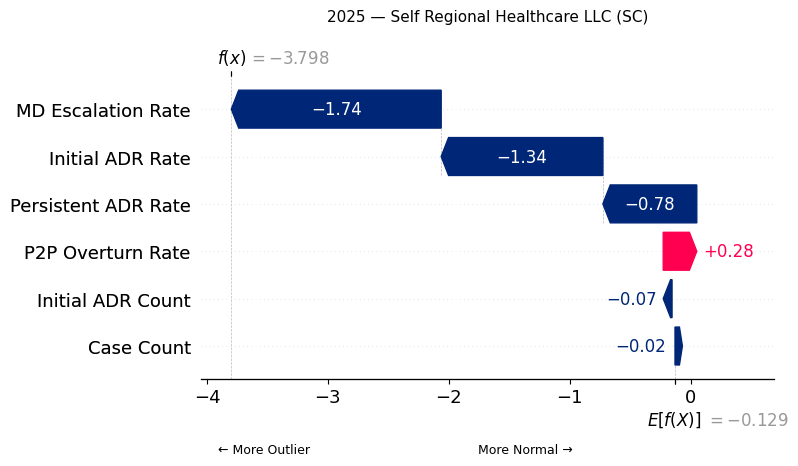

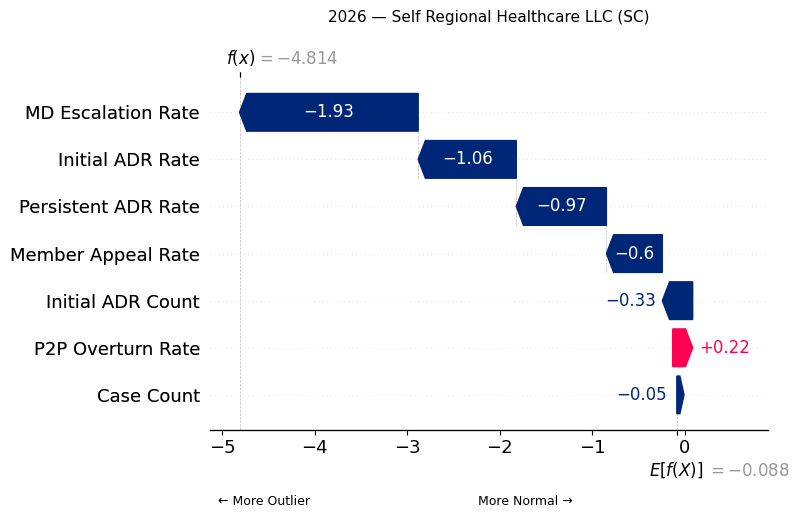

In [18]:
# ── Waterfall Plot: SELF REGIONAL HEALTHCARE LLC (All cohort only)
TARGET_HOSPITAL = 'SELF REGIONAL HEALTHCARE LLC'

# Set SHAP plot colors
from shap.plots._style import set_style
set_style(primary_color_negative = (0/255, 38/255, 119/255))  # #002677

KEEP_UPPER = {'LLC', 'LP', 'INC', 'MD', 'PA', 'SC', 'NC', 'FL', 'TX', 'NY', 'IL', 'GA', 'AL', 'MN', 'NJ', 'MI', 'WI', 'OK', 'CO', 'DC', 'MO'}

r = results['All']
for yr, feats, shap_key in [('2025', iso_kpi_6, 'shap_25'), ('2026', iso_kpi_7, 'shap_26')]:
    df_yr = r[yr]
    mask = df_yr['hospital_group'] == TARGET_HOSPITAL
    if not mask.any():
        continue
    pos = np.where(mask.values)[0][0]
    market = df_yr.iloc[pos]['fin_market']

    # Build Explanation from cached SHAP values (no refit)
    shap_vals = r[shap_key]
    display_names = [DRIVER_RENAME.get(f, f) for f in feats]
    explanation = shap.Explanation(
        values = shap_vals[pos],
        base_values = shap_vals.mean(axis = 0).sum(),
        data = None,
        feature_names = display_names
    )

    shap.plots.waterfall(explanation, max_display = len(feats), show = False)

    # Clean up: remove E[f(X)] and f(x) annotations
    ax = plt.gca()
    ax.set_xlabel('')
    for txt in plt.gcf().texts:
        txt.set_visible(False)
    for txt in ax.texts:
        txt.set_visible(False)

    hospital_name = ' '.join(w.upper() if w.upper() in KEEP_UPPER else w.capitalize() for w in TARGET_HOSPITAL.split())
    plt.title(f"{yr} — {hospital_name} ({market})\n", fontsize = 11)
    plt.figtext(0.5, -0.02, '\u2190 More Outlier                                          More Normal \u2192', ha = 'center', fontsize = 9)
    plt.tight_layout()
    plt.show()

In [ ]:
len(df_all_flagged[(df_all_flagged['cohort'] == 'All') & (df_all_flagged['driver'] == 'MD Escalation Rate')])

In [ ]:
df_all_flagged[df_all_flagged['cohort'] == 'All'].groupby('year').size()

In [ ]:
# Total hospital-markets in the 'All' model (before flagging)
print(f"2025: {len(results['All']['2025'])} hospitals")
print(f"2026: {len(results['All']['2026'])} hospitals")

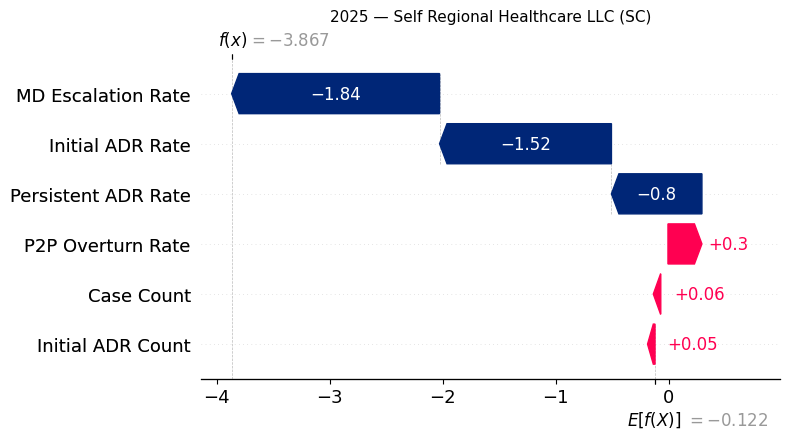

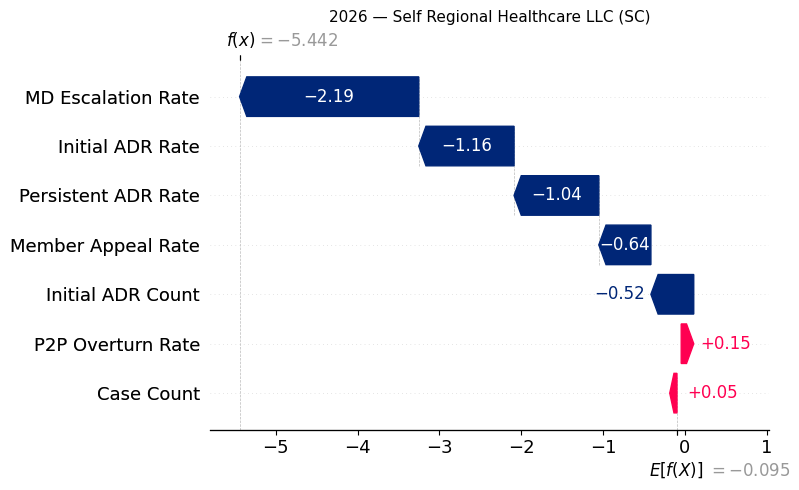

In [ ]:
# ── Waterfall Plot: SELF REGIONAL HEALTHCARE LLC (All cohort only)
TARGET_HOSPITAL = 'SELF REGIONAL HEALTHCARE LLC'

# Set SHAP plot colors
from shap.plots._style import set_style
set_style(primary_color_negative = (0/255, 38/255, 119/255))  # #002677

r = results['All']
for yr, feats, shap_key in [('2025', iso_kpi_6, 'shap_25'), ('2026', iso_kpi_7, 'shap_26')]:
    df_yr = r[yr]
    mask = df_yr['hospital_group'] == TARGET_HOSPITAL
    if not mask.any():
        continue
    pos = np.where(mask.values)[0][0]
    market = df_yr.iloc[pos]['fin_market']

    # Build Explanation from cached SHAP values (no refit)
    shap_vals = r[shap_key]
    display_names = [DRIVER_RENAME.get(f, f) for f in feats]
    explanation = shap.Explanation(
        values = shap_vals[pos],
        base_values = shap_vals.mean(axis = 0).sum(),
        data = None,
        feature_names = display_names
    )

    hospital_name = ' '.join(
        w.upper() if w.upper() in ('LLC', 'LP', 'INC', 'MD', 'PA', 'SC', 'NC', 'FL', 'TX', 'NY', 'IL', 'GA', 'AL', 'MN', 'NJ', 'MI', 'WI', 'OK', 'CO', 'DC', 'MO')
        else w.capitalize()
        for w in TARGET_HOSPITAL.split()
    )
    shap.plots.waterfall(explanation, max_display = len(feats), show = False)
    plt.title(f"{yr} — {hospital_name} ({market})", fontsize = 11)
    plt.tight_layout()
    plt.show()

In [11]:
df_monthly_out.to_csv(r"C:\Users\knguy139\Documents\Projects\Data\Output\flagged_iso_202607_v2.csv", index = False)